<a href="https://colab.research.google.com/github/Deepaksoni-dot/Deepaksoni-dot/blob/DeepLearning/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Problem Statement:
 The task at hand involves classifying images of cats and dogs using a
 Convolutional Neural Network (CNN). We have a dataset containing images of
 cats and dogs and the objective is to train a CNN model to accurately predict the class of each image

In [2]:
import tensorflow.keras as keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from keras.datasets import cifar10
import numpy as np

In [4]:
def lr_schedule(epoch):
  lrate=0.001
  if epoch>75:
    lrate=0.0005
  if epoch>100:
    lrate=0.0003
  return lrate

In [5]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
x_train= x_train.astype('float32')
x_test=x_test.astype('float32')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [6]:
#z score normalization
mean=np.mean(x_train,axis=(0,1,2,3))
std=np.std(x_train,axis=(0,1,2,3))
x_train=(x_train-mean)/(std+1e-7)
x_test=(x_test-mean)/(std+1e-7)

In [7]:
label=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [8]:
num_classes=10
y_train=keras.utils.to_categorical(y_train,num_classes)
y_test=keras.utils.to_categorical(y_test,num_classes)

In [9]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [10]:
x_train.shape

(50000, 32, 32, 3)

In [11]:
x_train[0,0,:,:]

array([[-0.9619245 , -0.91515917, -0.8995707 ],
       [-1.2113398 , -1.1645745 , -1.1801629 ],
       [-1.1022207 , -1.1333976 , -1.2113398 ],
       [-0.8216284 , -1.0398668 , -1.2269284 ],
       [-0.35397464, -0.7436861 , -1.0710437 ],
       [-0.026617  , -0.46309385, -0.8995707 ],
       [ 0.28515217, -0.21367851, -0.71250916],
       [ 0.3786829 , -0.16691314, -0.6345669 ],
       [ 0.44103676, -0.05779392, -0.49427077],
       [ 0.44103676, -0.01102854, -0.43191692],
       [ 0.1604445 , -0.27603233, -0.6813323 ],
       [ 0.06691375, -0.33838618, -0.69692075],
       [ 0.33191755, -0.08897084, -0.46309385],
       [ 0.36309445, -0.13573621, -0.5410361 ],
       [ 0.25397524, -0.24485542, -0.65015537],
       [ 0.12926759, -0.3695631 , -0.774863  ],
       [ 0.25397524, -0.22926697, -0.65015537],
       [ 0.20720987, -0.22926697, -0.69692075],
       [ 0.05132529, -0.3695631 , -0.88398224],
       [ 0.28515217, -0.12014776, -0.6657438 ],
       [ 0.28515217, -0.13573621, -0.712

In [12]:
y_train.shape

(50000, 10)

In [13]:
datagen=ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)
datagen.fit(x_train)

In [14]:
#CNN model
weight_decay=1e-4
model=keras.models.Sequential()
model.add(keras.layers.Conv2D(64,(3,3),padding='same',kernel_regularizer=keras.regularizers.l2(weight_decay),
                              input_shape=x_train.shape[1:]))
#here padding='same' means that op size=input size and using l2 regularizer and input shape (32,32,3) and (3,3) kernel size
model.add(keras.layers.Activation('elu'))
model.add(keras.layers.BatchNormalization())
#second layer
model.add(keras.layers.Conv2D(64,(3,3),padding='same',kernel_regularizer=keras.regularizers.l2(weight_decay)))
model.add(keras.layers.Activation('elu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(keras.layers.Dropout(0.3))
#third layer
model.add(keras.layers.Conv2D(128,(3,3),padding='same',kernel_regularizer=keras.regularizers.l2(weight_decay)))
model.add(keras.layers.Activation('elu'))
model.add(keras.layers.BatchNormalization())
# fourth layer
model.add(keras.layers.Conv2D(128,(3,3),padding='same',kernel_regularizer=keras.regularizers.l2(weight_decay)))
model.add(keras.layers.Activation('elu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))  # maximum value out of 2,2 matrix over the image
model.add(keras.layers.Dropout(0.4))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(10,activation='softmax'))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          81,930 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 343,626 (1.31 MB)

 Trainable params: 342,858 (1.31 MB)

 Non-trainable params: 768 (3.00 KB)

In [15]:
# import tensorflow as tf
# print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

In [16]:
#training
batch_size=64
opt_rms=keras.optimizers.RMSprop(learning_rate=0.001,decay=1e-6)
model.compile(loss='categorical_crossentropy',optimizer=opt_rms,metrics=['accuracy'])
model.fit(datagen.flow(x_train,y_train,batch_size=batch_size),
                    steps_per_epoch=x_train.shape[0]//batch_size,   #// floor division
                    epochs=30,verbose=1,validation_data=(x_test,y_test),
                    callbacks=[keras.callbacks.LearningRateScheduler(lr_schedule)])

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


781/781 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.3325 - loss: 3.1350 - val_accuracy: 0.5100 - val_loss: 2.0402 - learning_rate: 0.0010
Epoch 2/30
  1/781 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5781 - loss: 1.7215

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5781 - loss: 1.7215 - val_accuracy: 0.5127 - val_loss: 2.0033 - learning_rate: 0.0010
Epoch 3/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.5255 - loss: 1.6965 - val_accuracy: 0.6408 - val_loss: 1.2124 - learning_rate: 0.0010
Epoch 4/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5156 - loss: 1.3976 - val_accuracy: 0.6223 - val_loss: 1.2655 - learning_rate: 0.0010
Epoch 5/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.6035 - loss: 1.2670 - val_accuracy: 0.6793 - val_loss: 1.0413 - learning_rate: 0.0010
Epoch 6/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7812 - loss: 0.8986 - val_accuracy: 0.6765 - val_loss: 1.0526 - learning_rate: 0.0010
Epoch 7/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.6607 - loss: 1.0566 - val_accuracy: 0.6985 - val_loss: 0.9659 - learning_rate: 0.0010
Epoch 8/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6250 - loss: 1.1918 - val_a

In [17]:
# model_json=model.to_json()   # convert to json
# with open('model.json','w') as json_file:
#   json_file.write(model_json)   # add converted file in model.json
# model.save_weights('model.h5') # save weights in model.h5

ValueError: The filename must end in `.weights.h5`. Received: filepath=model.h5

In [18]:
#testing
scores=model.evaluate(x_test,y_test,batch_size=128,verbose=1)
print('Test loss:',scores[0])
print('Test accuracy:',scores[1])

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7762 - loss: 0.8228
Test loss: 0.8171232342720032
Test accuracy: 0.7804999947547913


In [21]:
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


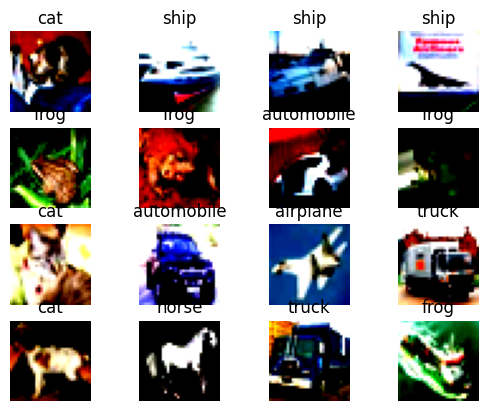

In [23]:
indices=np.argmax(model.predict(x_test[:16]),1)
#print([label[x] for x in indices])
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.axis('off')
  plt.title(label[indices[i]])
  plt.imshow(x_test[i])